In [2]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: Rcpp

scatterpie v0.2.6 Learn more at https://yulab-smu.top/



Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


ci

In [3]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [4]:
obj_mous_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/T313.100.rds')
obj_gene_all_merge <- readRDS('Analysis/obj_ST_gene_all.rds')
obj_mous_ST_OG <- obj_gene_all_merge[,obj_gene_all_merge$species=='mous']

mous_matrix <- as.matrix(obj_mous_ST_raw[['RNA']]@counts)[,obj_mous_ST_OG$cell_label_raw]
colnames(mous_matrix) <- colnames(obj_mous_ST_OG)
obj_mous_ST_gene <- obj_mous_ST_OG
obj_mous_ST_gene[['RNA']] <- CreateAssayObject(mous_matrix)
obj_mous_ST_gene@assays$RNA@data <- Matrix::t(Matrix::t(obj_mous_ST_gene@assays$RNA@counts)/colSums(obj_mous_ST_gene@assays$RNA@counts))

ERROR: Error in numeric_vector_group(obj_mous_ST_OG@meta.data[, "PrAl_celltype_raw"], : could not find function "numeric_vector_group"


In [7]:
#obj_marm_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/T454_bin100.rds')
obj_marm_ST_OG <- obj_gene_all_merge[,obj_gene_all_merge$species=='marm']

marm_matrix <- as.matrix(obj_marm_ST_raw[['RNA']]@counts)[,obj_marm_ST_OG$cell_label_raw]
colnames(marm_matrix) <- colnames(obj_marm_ST_OG)
obj_marm_ST_gene <- obj_marm_ST_OG
obj_marm_ST_gene[['RNA']] <- CreateAssayObject(marm_matrix)
obj_marm_ST_gene@assays$RNA@data <- Matrix::t(Matrix::t(obj_marm_ST_gene@assays$RNA@counts)/colSums(obj_marm_ST_gene@assays$RNA@counts))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 7.1 GiB”


In [11]:
obj_mous_ST_gene@active.assay <- 'RNA'
obj_mous_ST_gene <- NormalizeData(obj_mous_ST_gene)
obj_mous_ST_gene <- FindVariableFeatures(obj_mous_ST_gene,nfeatures = 3000)
obj_mous_ST_gene <- ScaleData(obj_mous_ST_gene,verbose=FALSE)
obj_mous_ST_gene <- RunPCA(obj_mous_ST_gene,npcs=30,verbose=FALSE)

In [34]:
saveRDS( obj_mous_ST_gene,'Analysis/Region_defined/Gene_mous.rds')

In [33]:
saveRDS( obj_mous_ST_gene@reductions$pca,'Analysis/Region_defined/Mous_redcution.rds')

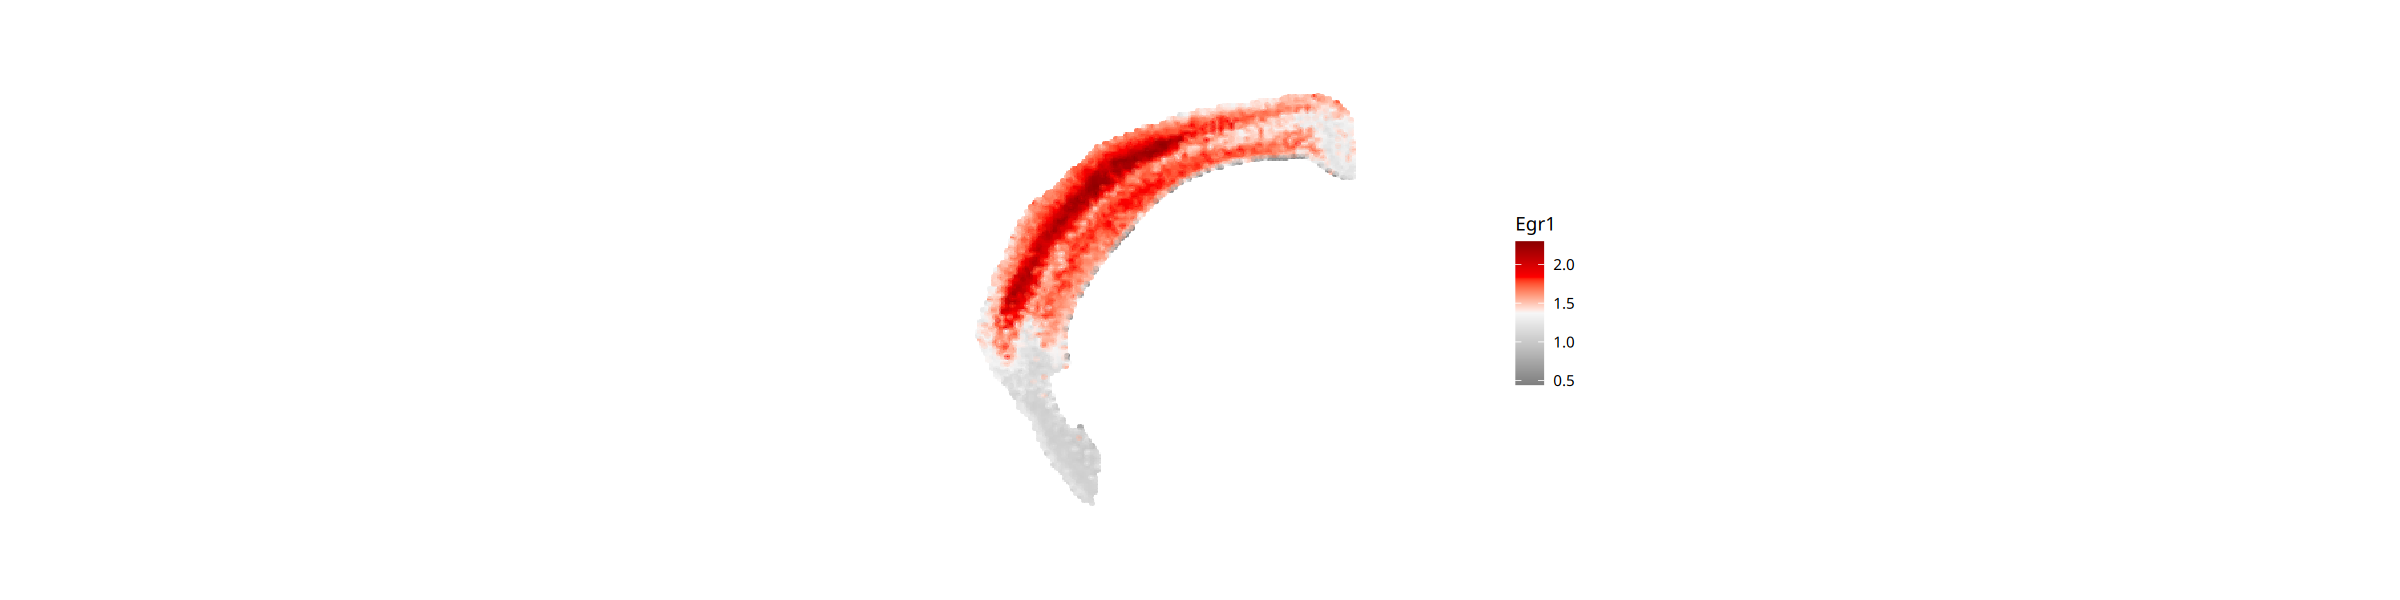

In [16]:
options(repr.plot.height=5,repr.plot.width=20)
plot_spatial_feature(obj = obj_mous_ST_gene,features = 'Egr1',height=150,width=170,assays='RNA',slot='data',smooth = T,smooth_function = 'magic')

In [17]:
obj_marm_ST_gene@active.assay <- 'RNA'
obj_marm_ST_gene <- NormalizeData(obj_marm_ST_gene)
obj_marm_ST_gene <- FindVariableFeatures(obj_marm_ST_gene,nfeatures = 3000)
obj_marm_ST_gene <- ScaleData(obj_marm_ST_gene,verbose=FALSE)
obj_marm_ST_gene <- RunPCA(obj_marm_ST_gene,npcs=30,verbose=FALSE)

In [32]:
saveRDS( obj_marm_ST_gene@reductions$pca,'Analysis/Region_defined/Marm_redcution.rds')

In [35]:
saveRDS( obj_marm_ST_gene,'Analysis/Region_defined/Gene_marm.rds')

In [3]:
obj_marm_ST_gene <- readRDS('Analysis/Region_defined/Gene_marm.rds')

In [5]:
obj_marm_ST_gene <- NormalizeData(obj_marm_ST_gene)

In [45]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_feature(obj = obj_marm_ST_gene,features = 'VAV3',assays='RNA',slot='data',smooth = T,round=1,knn=5,smooth_function = 'spatial',color=c("gray",'#cc5600',"#cc5600"))
pdf('Plot/Marm_gene_VAV3.pdf',width=20,height=5)
p
dev.off()

pdf 
  2

In [44]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_feature(obj = obj_marm_ST_gene,features = 'CNIH2',assays='RNA',slot='data',smooth = T,round=1,knn=5,smooth_function = 'magic',color=c("gray","#0091ad","#0091ad"))
pdf('Plot/Marm_gene_CNIH2.pdf',width=20,height=5)
p
dev.off()

pdf 
  2

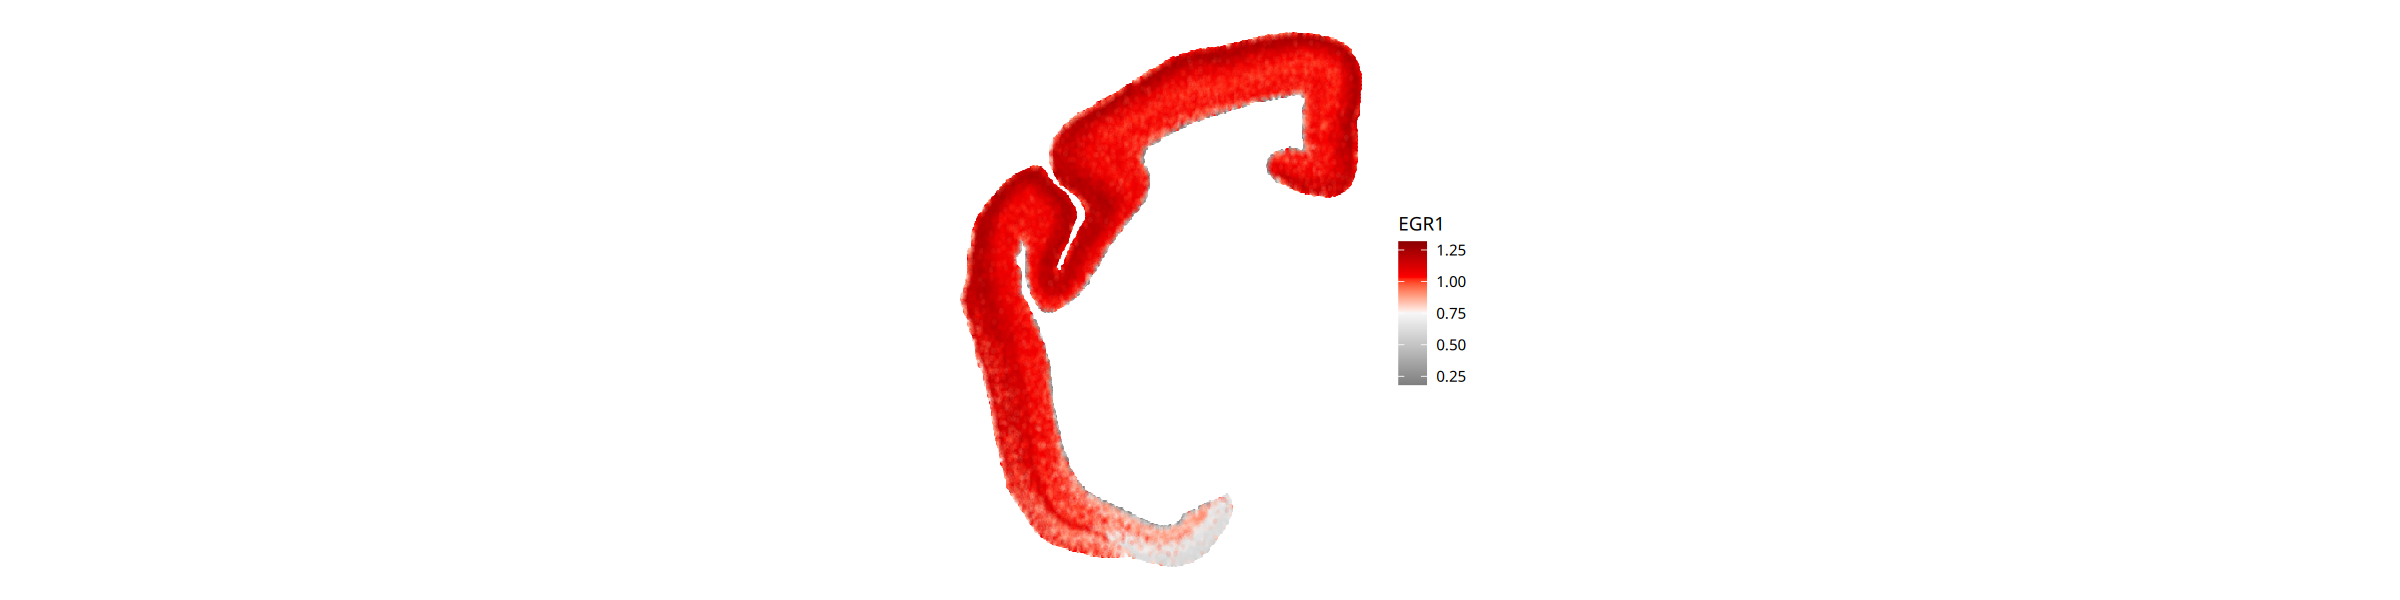

In [19]:
options(repr.plot.height=5,repr.plot.width=20)
plot_spatial_feature(obj = obj_marm_ST_gene,features = 'EGR1',assays='RNA',slot='data',smooth = T,smooth_function = 'magic')